---
# Topic Modelling
---

El **Topic Modelling** es un conjunto de técnicas de Procesamiento de Lenguaje Natural (PLN) cuyo objetivo es descubrir automáticamente los **temas latentes** presentes en un conjunto de documentos.

A diferencia del análisis de **keyness**, que identifica las palabras que distinguen grupos previamente definidos, el Topic Modelling busca responder una pregunta diferente:

> **¿Qué temas emergen naturalmente del corpus cuando no conocemos sus categorías de antemano?**

Por esta razón, el Topic Modelling se considera una técnica de **Aprendizaje No Supervisado** (*Unsupervised Machine Learning*).

---

## 🧠 ¿Qué es un tema?

En Topic Modelling, un **tema** (*topic*) no corresponde a una etiqueta predefinida, sino a una **distribución de probabilidad sobre las palabras** del vocabulario.

De manera intuitiva, un tema puede interpretarse como un conjunto de palabras que tienden a aparecer juntas en los documentos y que representan una idea o asunto común.

A su vez, cada documento puede estar compuesto por una mezcla de varios temas en distintas proporciones.

---

### 📌 ¿Cómo funciona?

Los algoritmos de Topic Modelling analizan los patrones de **frecuencia** y **co-ocurrencia** de las palabras para descubrir la estructura temática subyacente del corpus.

El resultado es una representación probabilística que permite:

- descubrir temas presentes en un conjunto de documentos;
- identificar qué documentos están más asociados a cada tema;
- resumir grandes corpus de manera automática;
- explorar colecciones de texto sin necesidad de etiquetas previas.

---

### 📊 Aplicaciones

El Topic Modelling tiene numerosas aplicaciones, entre ellas:

- Exploración de grandes corpus documentales.
- Organización automática de documentos por temática.
- Descubrimiento de tendencias en redes sociales, noticias o publicaciones científicas.
- Apoyo al análisis cualitativo en ciencias sociales, economía y finanzas.

---

## 🔍 El modelo que estudiaremos: **Latent Dirichlet Allocation (LDA)**

En este notebook trabajaremos con **Latent Dirichlet Allocation (LDA)**, uno de los modelos probabilísticos más influyentes en el desarrollo del Topic Modelling.

LDA representa:

- cada **documento** como una mezcla de temas;
- cada **tema** como una distribución de probabilidad sobre las palabras.

![Topic Modelling: corpus, mezcla de tópicos y distribución de palabras](../docs/images/topic_modeling_plot.png)

> 🧠 **Nota**
>
> Aunque en la actualidad existen métodos más modernos basados en **embeddings** y **transformers**, comprender **Latent Dirichlet Allocation (LDA)** sigue siendo fundamental, ya que constituye la base conceptual del modelamiento probabilístico de tópicos.
>
> En el siguiente notebook exploraremos **BERTopic**, un enfoque moderno que combina **embeddings**, técnicas de agrupamiento (*clustering*) y modelos de lenguaje para obtener tópicos generalmente más coherentes e interpretables.

> 📌 **Idea clave:** Mientras que el análisis de **keyness** compara grupos de documentos conocidos, el **Topic Modelling** descubre automáticamente la estructura temática de un corpus sin utilizar etiquetas previas.

In [1]:
#install.packages("quanteda")
#install.packages("quanteda.textmodels")
#install.packages("topicmodels")


In [2]:
library(quanteda)
library(quanteda.textmodels)
library(topicmodels)


Package version: 4.3.1
Unicode version: 14.0
ICU version: 71.1

Parallel computing: disabled

See https://quanteda.io for tutorials and examples.



In [3]:
library(data.table)
setDTthreads(16)        # Usa 16 núcleos 
getDTthreads()          # Verifica cuántos núcleos están activos


[1] 16

## I. Preparando los Datos

## 🧹 Preprocesamiento de texto para Topic Modelling

Antes de aplicar un modelo de temas (*Topic Modelling*), es esencial limpiar y transformar el texto para mejorar la calidad del análisis. El objetivo es reducir el ruido léxico y enfocarse en las palabras que realmente aportan información temática.

---

### 🧪 ¿Qué se hace en este preprocesamiento?

1. **Eliminar signos de puntuación, símbolos y números**  
   Estos elementos no contribuyen al contenido temático y pueden interferir con la detección de patrones léxicos.

2. **Eliminar palabras vacías (stopwords)**  
   Palabras como “the”, “is”, “and”, etc., son muy frecuentes pero carecen de contenido semántico relevante. Eliminarlas ayuda a resaltar las palabras clave que definen los temas.

---

### 🎯 ¿Por qué es importante para Topic Modelling?

- Mejora la **coherencia semántica** de los temas generados.
- Reduce la **dimensión del vocabulario**, acelerando los cálculos.
- Enfoca el modelo en las palabras que **distinguen mejor los tópicos** subyacentes.
- Aumenta la **interpretabilidad** de los resultados del modelo.

---

> ✅ Un preprocesamiento adecuado es crucial para obtener temas significativos y consistentes cuando se utiliza un algoritmo como **Latent Dirichlet Allocation (LDA)**.


In [4]:
toks <- data_corpus_moviereviews %>%
  tokens(remove_punct = TRUE, remove_symbols = TRUE, remove_numbers = TRUE) %>%
  tokens_remove(stopwords("en"))
toks



Warning message in (function (n) :
"strings not representable in native encoding will be translated to UTF-8"


Tokens consisting of 2,000 documents and 3 docvars.
cv000_29416.txt :
 [1] "plot"     "two"      "teen"     "couples"  "go"       "church"  
 [7] "party"    "drink"    "drive"    "get"      "accident" "one"     
[ ... and 314 more ]

cv001_19502.txt :
 [1] "happy"     "bastard's" "quick"     "movie"     "review"    "damn"     
 [7] "y2k"       "bug"       "got"       "head"      "start"     "movie"    
[ ... and 118 more ]

cv002_17424.txt :
 [1] "movies"    "like"      "make"      "jaded"     "movie"     "viewer"   
 [7] "thankful"  "invention" "timex"     "indiglo"   "watch"     "based"    
[ ... and 250 more ]

cv003_12683.txt :
 [1] "quest"          "camelot"        "warner"         "bros"          
 [5] "first"          "feature-length" "fully-animated" "attempt"       
 [9] "steal"          "clout"          "disney's"       "cartoon"       
[ ... and 258 more ]

cv004_12641.txt :
 [1] "synopsis"      "mentally"      "unstable"      "man"          
 [5] "undergoing"    "psychother

## 🔗 `tokens_compound()`

La función **`tokens_compound()`** se utiliza para combinar **tokens consecutivos** en unidades compuestas, permitiendo representar expresiones como una sola entidad léxica.

---

### 🧠 ¿Para qué sirve?

Agrupar tokens en secuencias fijas mejora la interpretación de términos que tienen un significado específico **como conjunto** y no como palabras aisladas.

Por ejemplo, expresiones como:

- `"New York"`
- `"human rights"`
- `"Star Wars"`

pueden perder contexto si se analizan como palabras individuales. Usar `tokens_compound()` permite tratarlas como **un solo token compuesto**, por ejemplo: `"Star_Wars"`.

---

### 🎬 Aplicación al corpus de críticas de películas

En este contexto, puede ser útil para:

- Distinguir correctamente franquicias como `"Star Wars"` vs `"Star Trek"`.
- Preservar nombres propios o títulos de películas como entidades semánticas completas.

---

> ✅ Esta función es especialmente útil cuando se dispone de una lista de expresiones clave (n-gramas) que se desean preservar como unidades durante el análisis de texto. Veamos un ejemplo:



In [5]:
example <- tokens("This is the third award winning movie of Cameron")

In [6]:
print(example)

Tokens consisting of 1 document.
text1 :
[1] "This"    "is"      "the"     "third"   "award"   "winning" "movie"  
[8] "of"      "Cameron"



In [7]:
foo <- tokens_compound(example, phrase("award winning"), concatenator = "-")
print(foo)

Tokens consisting of 1 document.
text1 :
[1] "This"          "is"            "the"           "third"        
[5] "award-winning" "movie"         "of"            "Cameron"      



Volvamos al corpus de las críticas de cine:

In [8]:
toks <- tokens_compound(toks, phrase(c("star wars", "star trek")))
toks

Tokens consisting of 2,000 documents and 3 docvars.
cv000_29416.txt :
 [1] "plot"     "two"      "teen"     "couples"  "go"       "church"  
 [7] "party"    "drink"    "drive"    "get"      "accident" "one"     
[ ... and 314 more ]

cv001_19502.txt :
 [1] "happy"     "bastard's" "quick"     "movie"     "review"    "damn"     
 [7] "y2k"       "bug"       "got"       "head"      "start"     "movie"    
[ ... and 118 more ]

cv002_17424.txt :
 [1] "movies"    "like"      "make"      "jaded"     "movie"     "viewer"   
 [7] "thankful"  "invention" "timex"     "indiglo"   "watch"     "based"    
[ ... and 250 more ]

cv003_12683.txt :
 [1] "quest"          "camelot"        "warner"         "bros"          
 [5] "first"          "feature-length" "fully-animated" "attempt"       
 [9] "steal"          "clout"          "disney's"       "cartoon"       
[ ... and 258 more ]

cv004_12641.txt :
 [1] "synopsis"      "mentally"      "unstable"      "man"          
 [5] "undergoing"    "psychother

In [9]:
dfmat <- dfm(toks) %>%
  dfm_trim(min_termfreq = 5)
dfmat


Document-feature matrix of: 2,000 documents, 14,872 features (98.37% sparse) and 3 docvars.
                 features
docs              plot two teen couples go church party drink drive get
  cv000_29416.txt    1   2    4       1  2      1     1     1     1   3
  cv001_19502.txt    0   0    0       0  0      0     0     0     0   1
  cv002_17424.txt    2   1    0       0  2      0     0     0     0   0
  cv003_12683.txt    0   0    0       0  0      0     0     0     0   0
  cv004_12641.txt    1   1    0       0  0      0     0     0     0   0
  cv005_29357.txt    1   0    0       0  0      0     0     0     0   0
[ reached max_ndoc ... 1,994 more documents, reached max_nfeat ... 14,862 more features ]

## ✂️ Filtrado de términos con `dfm_trim()`

Una vez creada la matriz documento-término (dfm), es habitual aplicar un proceso de filtrado para eliminar aquellas palabras que aparecen muy pocas veces. Esto permite reducir el ruido, mejorar la eficiencia computacional y concentrar el análisis en términos más representativos del corpus.

En este caso, se ha utilizado `dfm_trim()` para conservar únicamente los términos cuya frecuencia total en el corpus es igual o superior a 5. De este modo, se eliminan palabras extremadamente raras o poco informativas que podrían distorsionar el análisis posterior.

Este tipo de limpieza léxica es fundamental antes de aplicar modelos como análisis de tópicos, clustering, clasificación supervisada o visualización de frecuencias, ya que contribuye a una representación más significativa del texto.



## II. Ajustando un Topic Model

## 🔄 Conversión a formato para Topic Modelling

Para aplicar algoritmos de *Topic Modelling* como **LDA** desde paquetes especializados en R (por ejemplo, `topicmodels`), es necesario convertir la matriz de documento-término (`dfm`) a un formato compatible.

La función `convert()` permite transformar un objeto `dfm` de `quanteda` al formato requerido por otros paquetes. En este caso, se convierte al tipo **`DocumentTermMatrix`** utilizado por el paquete `topicmodels`.

---

### 🧠 ¿Por qué es necesaria esta conversión?

- `quanteda` y `topicmodels` utilizan estructuras internas diferentes.
- El modelo LDA de `topicmodels` requiere específicamente un objeto de tipo `DocumentTermMatrix` del paquete `tm`.
- La conversión asegura compatibilidad y permite aprovechar modelos probabilísticos avanzados sin reconstruir manualmente la matriz.

---

> ✅ Este paso es clave para integrar la potencia de preprocesamiento de `quanteda` con los algoritmos de modelado temático de `topicmodels`, como **Latent Dirichlet Allocation (LDA)**.


In [10]:
dfmat_tm <- convert(dfmat, to = "topicmodels")

In [11]:
?convert

convert                package:quanteda                R Documentation

_C_o_n_v_e_r_t _q_u_a_n_t_e_d_a _o_b_j_e_c_t_s _t_o _n_o_n-_q_u_a_n_t_e_d_a _f_o_r_m_a_t_s

_D_e_s_c_r_i_p_t_i_o_n:

     Convert a quanteda dfm or corpus object to a format useable by
     other packages. The general function 'convert' provides easy
     conversion from a dfm to the document-term representations used in
     all other text analysis packages for which conversions are
     defined.  For corpus objects, 'convert' provides an easy way to
     make a corpus and its document variables into a data.frame.

_U_s_a_g_e:

     convert(x, to, ...)
     
     ## S3 method for class 'dfm'
     convert(
       x,
       to = c("lda", "tm", "stm", "austin", "topicmodels", "lsa", "matrix", "data.frame",
         "tripletlist"),
       docvars = NULL,
       omit_empty = TRUE,
       docid_field = "doc_id",
       ...
     )
     
     ## S3 method for class

## 🧾 Creación de la Matriz Documento-Término (Document-Term Matrix)

La **matriz documento-término** representa la frecuencia con la que aparece cada término en cada documento del corpus. En esta matriz:

- Las **filas** corresponden a documentos individuales.
- Las **columnas** representan términos únicos del vocabulario.
- Las **celdas** contienen el número de veces que un término aparece en un documento dado.

Esta estructura es esencial para una amplia gama de análisis de texto, incluyendo clasificación, clustering y modelado de temas.

---

### 🔄 Conversión desde `dfm` a `DocumentTermMatrix`

Aunque en `quanteda` trabajamos con matrices del tipo `dfm` (document-feature matrix), muchos otros paquetes de R —como `topicmodels` o `stm`— utilizan la clase `DocumentTermMatrix` del paquete `tm`.

La función **`convert()`** facilita esta interoperabilidad al transformar directamente un `dfm` en una `DocumentTermMatrix`, permitiendo así aplicar modelos como **Latent Dirichlet Allocation (LDA)** sin necesidad de reconstruir manualmente la estructura de datos.

---

> ✅ Este paso es clave para combinar el preprocesamiento potente de `quanteda` con las capacidades analíticas de otros paquetes especializados.




In [12]:
class(dfmat_tm)

[1] "DocumentTermMatrix"    "simple_triplet_matrix"

## 📚 Latent Dirichlet Allocation (LDA)

**Latent Dirichlet Allocation (LDA)** es un algoritmo de *Topic Modelling* que permite descubrir temas latentes dentro de un conjunto de documentos. Parte de la premisa de que:

- Cada **documento** es una mezcla de distintos **tópicos**.
- Cada **tópico** es una distribución de probabilidad sobre un conjunto de **palabras**.

---

### 🧠 Supuestos clave del modelo

1. **Hipótesis de Mezcla**:  
   Cada documento contiene una mezcla de tópicos. La distribución de estos temas sigue una distribución de Dirichlet.

2. **Hipótesis de Generación**:  
   Cada palabra en un documento se genera en dos pasos:
   - Se selecciona un tópico a partir de la distribución de tópicos del documento.
   - Se elige una palabra de la distribución de palabras correspondiente a ese tópico.

---

### 🧪 Ejemplo conceptual

Un artículo sobre el uso de redes sociales por parte del gobierno podría estar compuesto por una mezcla de los tópicos “tecnología” y “política”.  
- El tópico *tecnología* puede incluir palabras como *“software”, “computadora”, “innovación”*.  
- El tópico *política* puede tener alta probabilidad para palabras como *“gobierno”, “ley”, “ministerio”*.

---

### ⚙️ Funcionamiento del algoritmo

1. **Inicialización**: Se fija el número de tópicos `k` y se inicializan las distribuciones aleatoriamente.
2. **Asignación de tópicos**: Cada palabra se asigna provisionalmente a un tópico, según las distribuciones actuales.
3. **Actualización**: Se ajustan las distribuciones de palabras por tópico y de tópicos por documento.
4. **Iteración**: Se repiten los pasos hasta alcanzar la convergencia.

---

### 🔍 Resultado final

El modelo entrega:
- Una **distribución de tópicos para cada documento**.
- Una **distribución de palabras para cada tópico**.

Estas salidas permiten interpretar de forma automatizada qué temas predominan en cada documento y qué palabras los caracterizan.

---

### 📌 Parámetros clave del modelo LDA (`topicmodels::LDA()` en R)

- `k`: número de tópicos a extraer.
- `method`: método de estimación (e.g., `"VEM"` o `"Gibbs"`).
- `control`: lista de hiperparámetros para controlar el algoritmo (e.g., número de iteraciones, semilla, etc.).

---

> ✅ LDA es un método de *aprendizaje no supervisado*, lo que significa que no requiere etiquetas previas y descubre la estructura temática directamente desde los datos observados.

🔗 Recurso recomendado:  
[Beginner’s Guide to Topic Modelling – Analytics Vidhya](https://www.analyticsvidhya.com/blog/2016/08/beginners-guide-to-topic-modeling-in-python/)


## ⚙️ Métodos de Estimación en LDA: VEM vs. Gibbs Sampling

Cuando se entrena un modelo **Latent Dirichlet Allocation (LDA)**, es necesario utilizar un método de inferencia para estimar las distribuciones de tópicos y palabras. Los dos métodos más comunes en R (`topicmodels::LDA`) son:

---

### 🔹 VEM – Variational Expectation-Maximization

- Utiliza una técnica de **optimización determinística**.
- Se basa en aproximar las distribuciones de probabilidad mediante funciones más manejables (variacionales).
- Converge rápidamente y es adecuado para conjuntos de datos grandes.
- Método por defecto en `topicmodels`.

**Ventajas**: Rápido, reproducible (menos aleatoriedad).  
**Desventajas**: Puede subestimar la variabilidad y quedar atrapado en óptimos locales.

---

### 🔸 Gibbs Sampling

- Es un método de **MCMC (Markov Chain Monte Carlo)** basado en simulaciones aleatorias.
- Asigna iterativamente tópicos a palabras utilizando muestreo condicional.
- Tiende a capturar mejor la **estructura real** del modelo, especialmente en corpora pequeños o ruidosos.

**Ventajas**: Estimaciones más precisas y flexibles.  
**Desventajas**: Más lento, necesita muchas iteraciones, resultado más sensible a la semilla.

---

### 🧠 ¿Cuál usar?

- **VEM**: cuando se necesita rapidez, reproducibilidad y se trabaja con grandes volúmenes de texto.
- **Gibbs**: cuando se prioriza la calidad de la inferencia y se dispone de mayor poder computacional.

> ✅ Ambos métodos buscan el mismo objetivo: estimar la distribución de tópicos y palabras en el corpus. La elección depende del equilibrio entre precisión y velocidad.


In [13]:
set.seed(2)
tmod_20 <- LDA(dfmat_tm,
            k = 20,
            method = "Gibbs",
            control = list(alpha = 0.02, delta = 0.02))

## 🧪 Estimación de un modelo LDA con Gibbs Sampling

En este paso, se entrena un modelo de **Latent Dirichlet Allocation (LDA)** utilizando el método de inferencia **Gibbs Sampling**. El modelo se ajusta sobre la matriz documento-término previamente convertida y especifica que se desea identificar **20 tópicos** latentes en el corpus.

---

### ⚙️ Parámetros clave

- **`k = 20`**: Se define que el modelo debe extraer 20 tópicos.
- **`method = "Gibbs"`**: Se emplea el muestreador de Gibbs, un algoritmo MCMC que realiza inferencia estocástica.
- **`alpha = 0.02`**: Controla la dispersión de tópicos por documento. Un valor bajo tiende a generar documentos con pocos temas dominantes.
- **`delta = 0.02`** (a veces llamado `beta` en la literatura): Controla la dispersión de palabras por tópico. Un valor bajo produce tópicos más especializados (menos palabras comunes compartidas entre tópicos).
- **`set.seed(2)`**: Se establece una semilla para asegurar la reproducibilidad de los resultados.

---

### 🧠 ¿Qué produce este modelo?

Al finalizar la estimación, el modelo entrega:

- Una **distribución de tópicos por documento** (¿qué temas predominan en cada texto?).
- Una **distribución de palabras por tópico** (¿qué palabras caracterizan cada tema?).

Estas salidas permiten interpretar el contenido latente del corpus y explorar la estructura temática de los documentos.

> ✅ Gibbs Sampling es especialmente útil cuando se busca capturar estructuras semánticas más precisas, aunque requiere mayor poder de cómputo que métodos deterministas como VEM.


In [14]:
terms(tmod_20, 15)


Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12,Topic 13,Topic 14,Topic 15,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20
truman,effects,effects,life,love,love,good,movie,sam,action,horror,film,war,game,batman,disney,sex,film,joe,comedy
show,alien,special,world,life,death,sean,bad,max,jackie,scream,jackie,action,bill,crime,story,school,one,de,funny
series,ship,vampire,film,family,story,chris,like,carter,chan,film,girls,men,reality,jack,animated,scene,movie,apes,jokes
star_trek,special,book,film's,mother,angels,cage,just,wild,fight,killer,mr,battle,dog,action,animation,high,like,big,humor
carrey,aliens,horror,young,romantic,god,wrestling,one,things,van,movie,nights,john,computer,harry,voice,people,just,wife,big
television,planet,city,one,comedy,shakespeare,hunting,get,kelly,hong,first,tarantino,ryan,stone,arnold,tarzan,sexual,even,michael,laughs
contact,earth,vampires,man,woman,annie,van,even,performance,bond,original,brown,spielberg,bulworth,robin,family,party,time,dude,comic
x-files,space,dark,american,wife,black,men,guy,funny,scenes,still,music,army,system,police,toy,girls,can,tim,high
first,film,house,new,father,king,8mm,movies,charlie,kong,summer,musical,thriller,douglas,cop,kids,women,much,rick,smith
movie,star_wars,spawn,story,relationship,derek,welles,know,nothing,martial,last,wedding,soldiers,black,brooks,mulan,girl,good,scorsese,hilarious


In [48]:
class(terms(tmod_20, 15))

[1] "matrix" "array"

## Escogiendo el Valor de $k$

El valor que se escoja para $k$ afecta el desempeño del modelo.

**Valor de $k$ alto**: Si el valor de $k$ es muy alto, las listas de tópicos se pueden superponer. Si se disminuye el valor de $k$, se logra que palabras de tópicos similares se agrupen para formar una menor cantidad de tópicos más coherentes. 

*   Con valores de $k$ muy altos, se produce **overfitting**.  El modelo puede empezar a sobreajustar los datos, lo que significa que aprenderá características demasiado específicas y ruidosas de los documentos de entrenamiento.

*   A medida que aumenta el número de tópicos, es posible que algunos de ellos sean muy similares entre sí o incluso representen pequeñas diferencias semánticas. Esto puede dificultar la interpretación y utilidad de los tópicos identificados, ya que pueden volverse demasiado específicos o superpuestos.

*   Un valor alto de $k$ implica que hay más parámetros que el modelo necesita aprender, lo que puede aumentar significativamente la complejidad computacional y el tiempo de entrenamiento del algoritmo LDA.

Si se disminuye el valor de $k$, se logra que palabras de tópicos similares se agrupen para formar una menor cantidad de tópicos más coherentes. 

**Valor de $k$ es bajo**: Si el valor de $k$ es demasiado bajo,puede suceder que palabras no relacionadas se agrupen en unos pocos tópicos. 

*   Si el valor de $k$ es muy bajo, el modelo puede no ser capaz de capturar la diversidad y complejidad de los temas presentes en los datos. Se produce **underfitting**. Como resultado, algunos temas importantes pueden quedar subrepresentados o incluso omitirse por completo.

*   Un número muy bajo de temas puede llevar a una simplificación excesiva de los datos, lo que significa que se pierden detalles y matices importantes presentes en los documentos originales.

*   Con un valor bajo de $k$, algunos tópicos pueden ser muy amplios y vagos, lo que lleva a la identificación de temas que engloban múltiples conceptos distintos. Esto puede dificultar la interpretación precisa y la asignación adecuada de documentos a tópicos específicos.

*   Un número muy bajo de tópicos puede hacer que el modelo sea menos discriminativo, lo que significa que los tópicos identificados pueden compartir muchas palabras clave y no tener características distintivas claras.

*   Al incrementar $k$, se logra que las palabras se separen en tópicos más distintivos.



## 🎯 Elección del Número de Tópicos ($k$) en LDA

El valor que se elige para $k$, es decir, el número de tópicos que el modelo LDA debe identificar, afecta significativamente tanto el rendimiento del modelo como la interpretabilidad de los resultados.

---

### 🔺 Cuando $k$ es demasiado **alto**

- El modelo puede generar tópicos **redundantes** o **superpuestos**, con palabras muy similares que pertenecen a varios temas.
- Aumenta el riesgo de **overfitting**, capturando ruido o particularidades irrelevantes del corpus.
- Se incrementa la **complejidad computacional**, ya que el modelo debe aprender más parámetros.
- Los tópicos tienden a ser **más específicos**, lo que puede dificultar su interpretación.

📌 Resultado: Tópicos más fragmentados, menos generalizables y potencialmente redundantes.

---

### 🔻 Cuando $k$ es demasiado **bajo**

- El modelo agrupa en un mismo tópico **palabras no relacionadas**, lo que disminuye la coherencia temática.
- Se produce **underfitting**, omitiendo detalles importantes y simplificando excesivamente el contenido.
- Los tópicos se vuelven **amplios, vagos y poco discriminativos**, compartiendo muchas palabras clave.
- Disminuye la **capacidad explicativa** del modelo sobre la estructura latente del corpus.

📌 Resultado: Tópicos demasiado genéricos, difíciles de interpretar y poco útiles para análisis específicos.

---

### ✅ ¿Qué hacer?

La elección óptima de $k$ depende del corpus y los objetivos del análisis. Existen métodos como:

- Evaluación de **coherencia temática**.
- Uso de medidas de **log-verosimilitud**.
- Comparación de resultados con distintas configuraciones.
- Validación cruzada o interpretación cualitativa de los tópicos.

> 🎯 En general, se busca un equilibrio entre **precisión**, **coherencia semántica** y **utilidad interpretativa** de los temas extraídos.


Reptimaos nuestro análisis con $k=12$ y con $k=25$:

In [15]:
set.seed(2)
tmod_12 <- LDA(dfmat_tm,
            k = 12 , 
            method = "Gibbs",
            control = list(alpha = 0.02, delta = 0.02))

In [16]:
terms(tmod_12, 15)

Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,Topic 11,Topic 12
truman,effects,batman,love,horror,action,disney,film,film,film,war,comedy
show,alien,wild,life,scream,jackie,story,one,movie,performance,men,funny
world,special,sex,family,killer,crime,animated,story,one,also,battle,big
life,aliens,film,woman,vampire,plot,animation,life,like,well,man,humor
angels,ship,mr,wife,original,cop,voice,characters,just,character,army,jokes
reality,planet,kevin,mother,scary,chan,tarzan,character,even,best,american,john
patch,action,arnold,romantic,s,s,family,new,good,great,black,also
television,film,robin,man,house,role,little,world,can,cast,action,comic
people,space,troopers,relationship,vampires,van,kids,film's,time,good,spielberg,laughs
political,earth,nights,comedy,sequel,films,toy,two,get,ending,private,ben


In [17]:
set.seed(2)
tmod_25 <- LDA(dfmat_tm,
            k = 25 , 
            method = "Gibbs",
            control = list(alpha = 0.02, delta = 0.02))

In [18]:
terms(tmod_25, 15)

Topic 1,Topic 2,Topic 3,Topic 4,Topic 5,Topic 6,Topic 7,Topic 8,Topic 9,Topic 10,...,Topic 16,Topic 17,Topic 18,Topic 19,Topic 20,Topic 21,Topic 22,Topic 23,Topic 24,Topic 25
show,film,star_wars,alien,batman,love,black,scream,tarzan,movie,...,war,jackie,sean,film,disney,sex,vampire,movie,house,titanic
truman,one,godzilla,effects,mr,family,things,horror,king,film,...,political,tarantino,max,good,animated,troopers,joe,bad,horror,comedy
carrey,story,star_trek,aliens,robin,life,sex,killer,classic,one,...,men,fiction,williams,movie,family,starship,john,guy,david,bob
movie,life,effects,ship,nights,mother,sam,school,mel,like,...,battle,robert,de,one,story,violence,vampires,action,blair,american
television,characters,special,earth,apes,father,wild,last,story,just,...,american,drug,character,really,animation,cage,spawn,movies,witch,kevin
series,also,lucas,action,tim,woman,shakespeare,summer,jane,even,...,army,l,role,well,kids,verhoeven,comic,get,scary,funny
x-files,character,phantom,planet,boogie,wife,white,teen,william,time,...,ryan,pulp,scorsese,also,little,kevin,blade,just,ghost,ben
nbsp,many,menace,space,burton,daughter,performance,julie,warrior,can,...,soldiers,brown,plays,just,voice,bacon,city,effects,effects,smith
world,young,jedi,mars,series,romantic,joe,first,men,good,...,private,harry,hunting,great,toy,porn,big,disaster,haunting,jay
murphy,film's,contact,science,hollow,husband,high,slasher,horse,get,...,spielberg,jackson,nick,much,children,plays,crow,sequence,de,simon


## 🎯 Discusión: Efecto del Número de Tópicos (\(k\)) en LDA

El número de tópicos (\(k\)) es un hiperparámetro fundamental en el modelamiento de temas con LDA. Afecta directamente la calidad, la coherencia y la utilidad interpretativa de los resultados. A continuación, se discute el efecto de elegir valores distintos de \(k\), usando los resultados para \(k = 12\), \(k = 20\) y \(k = 25\).

---

### 🔍 Coherencia Temática

- **\(k = 12\):**
  - Los temas son más **amplios y genéricos**.
  - Algunos tópicos agrupan palabras poco relacionadas, reflejando menor coherencia semántica.
  - Ejemplo: el *Topic 4* contiene “relationship”, “romantic”, “comedy”, “man”, lo que sugiere una mezcla amplia pero vaga.

- **\(k = 20\):**
  - Aumenta la **coherencia temática** y la **diferenciación entre tópicos**.
  - Se observan temas mejor definidos, como ciencia ficción, relaciones familiares, animación infantil, etc.
  - Ejemplo: aparecen tópicos centrados en “Star Trek / X-Files”, “love/life/family”, o “disney/animated”.

- **\(k = 25\):**
  - Surgen tópicos **muy específicos** o **redundantes**.
  - Algunos temas se solapan y contienen términos muy similares.
  - Aunque se capta más detalle, también crece el riesgo de **overfitting** y pérdida de claridad temática.

---

### ⚖️ Balance General

| Aspecto                 | \(k = 12\)                  | \(k = 20\)                           | \(k = 25\)                          |
|-------------------------|-----------------------------|--------------------------------------|-------------------------------------|
| Coherencia Temática     | Baja                        | Alta (buena separación)              | Irregular (algunos solapamientos)   |
| Interpretabilidad       | Difusa                      | Alta                                 | Media a baja                        |
| Granularidad            | Muy general                 | Equilibrada                          | Muy específica                      |
| Riesgo de Overfitting   | Bajo                        | Medio                                | Alto                                |
| Riesgo de Underfitting  | Alto                        | Bajo                                 | Muy bajo                            |

---

### ✅ Recomendación

En este corpus específico, un valor de \(k = 20\) ofrece un **equilibrio óptimo** entre especificidad, coherencia y capacidad interpretativa. 

- Evita los riesgos de generalización excesiva observados con \(k = 12\).
- Limita la fragmentación y redundancia presente con \(k = 25\).
- Permite analizar tópicos que son conceptualmente significativos y útiles para interpretación cualitativa.

> 💡 La selección óptima de \(k\) puede apoyarse con métricas como *coherencia temática*, *log-verosimilitud*, o validación cruzada, complementadas por juicio experto.


## 📊 III. Visualización de los Tópicos

Una vez estimado el modelo LDA y determinado un valor apropiado para \(k\), es fundamental **visualizar los resultados** para interpretar los tópicos, sus palabras clave y su distribución en los documentos.

### 🔍 ¿Qué se puede visualizar?

- **Principales palabras por tópico:** permite identificar el contenido semántico de cada tema.
- **Distribución de tópicos por documento:** muestra cómo se mezclan los temas en cada texto.
- **Relación entre tópicos:** mediante mapas o gráficos de similitud.







In [19]:
install.packages("tidyverse")
install.packages("tidytext")
install.packages("reshape2")


The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpgMEks6/downloaded_packages

The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpgMEks6/downloaded_packages

The downloaded binary packages are in
	/var/folders/8q/0f19vqjs5hn942n9xdsj2lc80000gn/T//RtmpgMEks6/downloaded_packages


In [20]:
library(tidyverse)
library(tidytext)
library(reshape2)

-- Attaching core tidyverse packages ------------------------ tidyverse 2.0.0 --
v dplyr     1.1.4     v readr     2.1.5
v forcats   1.0.0     v stringr   1.5.1
v ggplot2   3.5.2     v tibble    3.3.0
v lubridate 1.9.4     v tidyr     1.3.1
v purrr     1.1.0     
-- Conflicts ------------------------------------------ tidyverse_conflicts() --
x dplyr::between()     masks data.table::between()
x dplyr::filter()      masks stats::filter()
x dplyr::first()       masks data.table::first()
x lubridate::hour()    masks data.table::hour()
x lubridate::isoweek() masks data.table::isoweek()
x dplyr::lag()         masks stats::lag()
x dplyr::last()        masks data.table::last()
x lubridate::mday()    masks data.table::mday()
x lubridate::minute()  masks data.table::minute()
x lubridate::month()   masks data.table::month()
x lubridate::quarter() masks data.table::quarter()
x lubridate::second()  masks data.table::second()
x purrr::transpose()   masks data.table::transpose()
x lubridate::wday() 

## 📥 Extracción de Términos por Tópico: Matriz Beta

Una vez entrenado el modelo LDA, el siguiente paso es **extraer las probabilidades de cada palabra en cada tópico**, lo que nos permite entender cuáles términos son más representativos de cada tema descubierto.

Utilizamos la función `tidy()` del paquete **tidytext** para convertir el modelo en un formato "ordenado" (*tidy*) y extraer la **matriz beta**, que contiene:

- `topic`: el número del tópico (de 1 a $k$),
- `term`: la palabra o token,
- `beta`: la probabilidad de que esa palabra esté asociada al tópico.

Esto se expresa como:

```r
topics <- tidy(tmod_20, matrix = "beta")
```

La salida tiene la siguiente estructura:

| topic | term     | beta       |
|-------|----------|------------|
| 1     | truman   | 0.012345   |
| 1     | show     | 0.011672   |
| 1     | series   | 0.009875   |
| ...   | ...      | ...        |

> 📌 Esta tabla nos permite identificar, por cada tópico, **qué palabras tienen mayor peso probabilístico** ($\beta$) y por tanto son más relevantes temáticamente.

Posteriormente, filtraremos los términos con mayor beta por tópico para generar visualizaciones como **wordclouds** o **gráficos de barras**.


In [21]:
topics <- tidytext::tidy(tmod_20, matrix = "beta")
head(topics)

topic,term,beta
<int>,<chr>,<dbl>
1,plot,3.340884e-06
2,plot,3.045599e-03
3,plot,2.181158e-06
4,plot,2.779035e-07
5,plot,1.042512e-06
6,plot,2.160557e-04


## 🔝 Términos Más Representativos por Tópico

Para interpretar los temas generados por el modelo LDA, es útil identificar las palabras más representativas de cada tópico. Esto se logra seleccionando aquellas con mayor probabilidad ($\beta$) dentro de cada grupo temático.

Utilizamos `top_n()` para extraer, por ejemplo, los 10 términos con mayor peso por tópico:

```r
topterms <- topics %>%
  group_by(topic) %>%
  top_n(10, beta) %>%
  ungroup() %>%
  arrange(topic, -beta)
```

Esta tabla ordenada contiene:

- `topic`: número del tópico,
- `term`: palabra considerada,
- `beta`: peso o probabilidad de aparición del término en ese tópico.

Este resumen facilita la exploración temática y sirve de base para:

- generar **nubes de palabras** temáticas,
- comparar contenidos entre tópicos,
- o bien **asignar manualmente etiquetas semánticas** a cada tópico.

> 🎯 En conjunto con visualizaciones, esta información permite comprender de manera intuitiva qué temas emergen del corpus analizado.


In [22]:
topterms <-
  topics %>%
  group_by(topic) %>%
  top_n(10, beta) %>%
  # top_n selecciona las 10 primeras filas basándose en el valor "beta".
  ungroup() %>%
  arrange(topic, -beta)

head(topterms)

topic,term,beta
<int>,<chr>,<dbl>
1,truman,0.02155204
1,show,0.02138500
1,series,0.01887933
1,star_trek,0.01687480
1,carrey,0.01303279
1,television,0.01136235


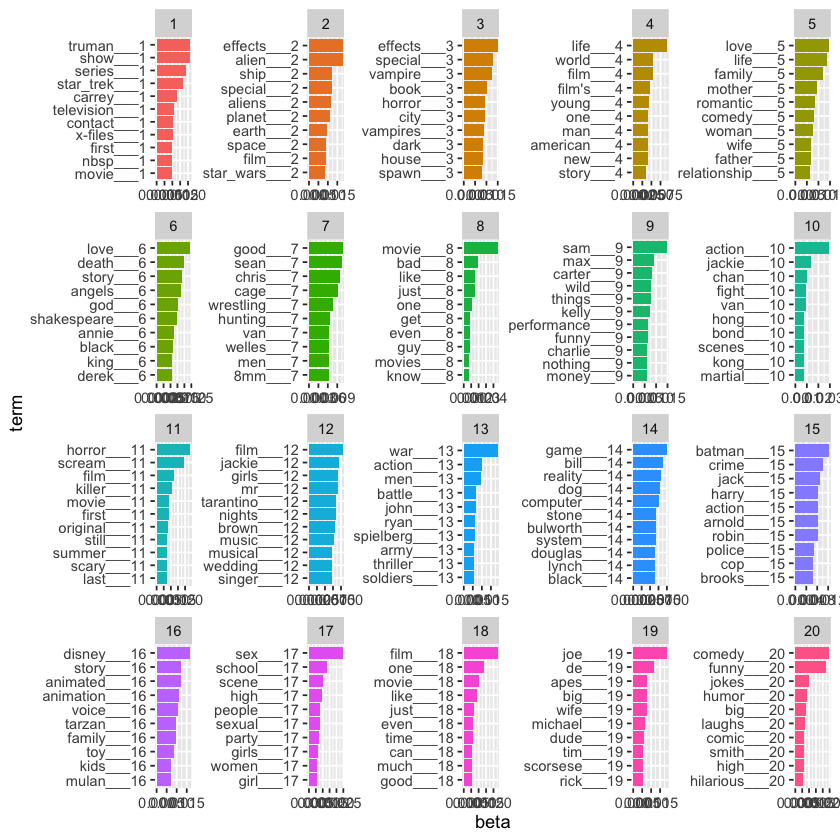

In [52]:
topterms %>%
  mutate(term = reorder_within(term, beta,topic)) %>%
  ggplot(aes(term, beta, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  # specifies bar charts, removes legend
  facet_wrap(~ topic, scales = "free") +
  # creates separate plots by topic, with x-axis scale independent of each other
  coord_flip()
  # flips x and y axes

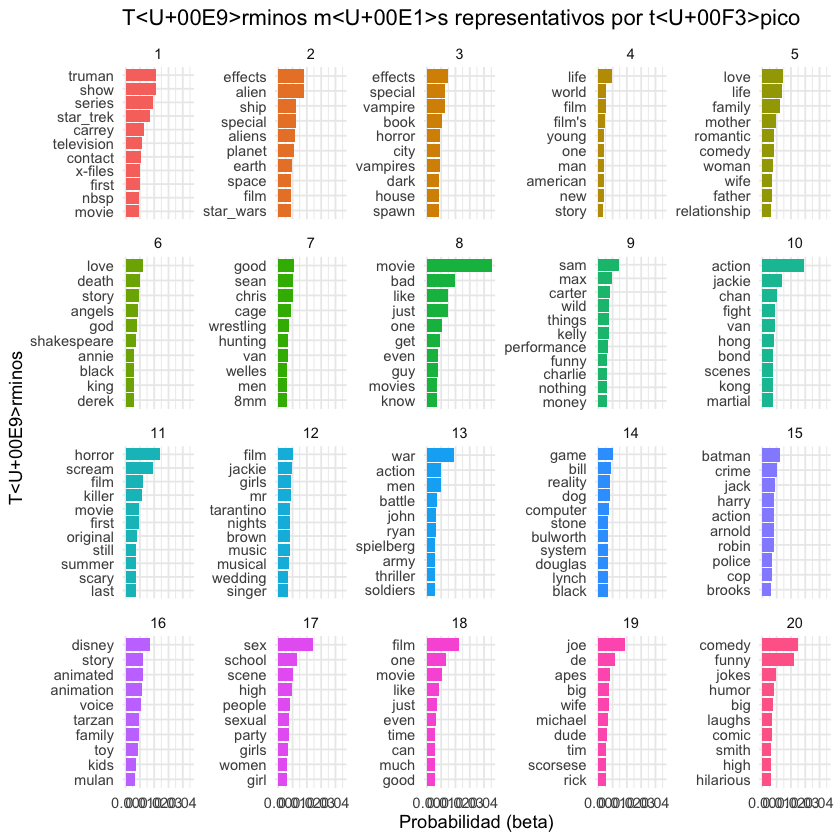

In [49]:
topterms %>%
  mutate(term = reorder_within(term, beta, topic)) %>%
  ggplot(aes(x = beta, y = term, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free_y") +
  scale_y_reordered() +
  theme_minimal() +
  labs(x = "Probabilidad (beta)", y = "Términos", title = "Términos más representativos por tópico")


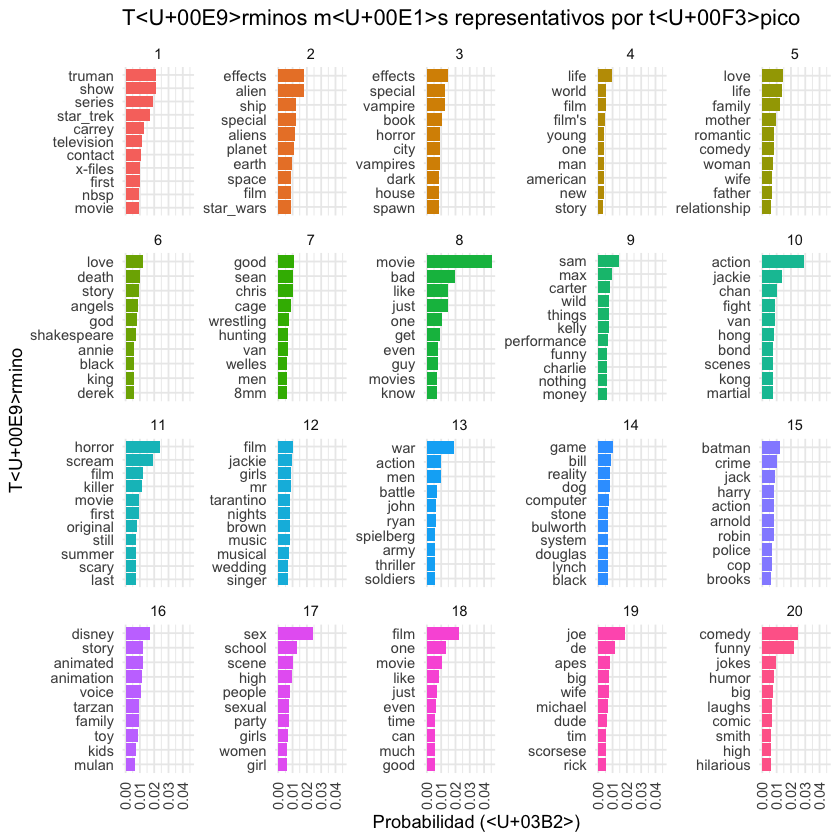

In [25]:
topterms %>%
  mutate(term = tidytext::reorder_within(term, beta, topic)) %>%
  ggplot(aes(x = beta, y = term, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free_y") +
  scale_y_reordered() +
  labs(
    title = "Términos más representativos por tópico",
    x = "Probabilidad (β)",
    y = "Término"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, vjust = 0.5, hjust = 1)  # 👈 etiquetas del eje X en vertical
  )

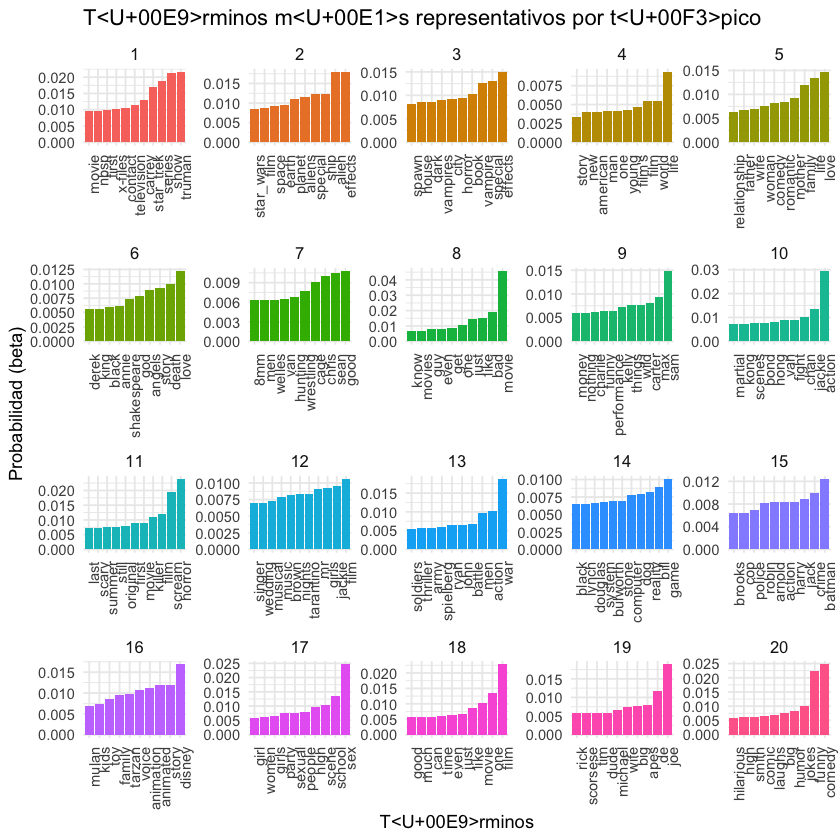

In [50]:
topterms %>%
  mutate(term = reorder_within(term, beta, topic)) %>%
  ggplot(aes(x = term, y = beta, fill = factor(topic))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ topic, scales = "free") +
  scale_x_reordered() +  # requiere library(tidytext)
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 90, hjust = 1),
    strip.text = element_text(size = 10)
  ) +
  labs(x = "Términos", y = "Probabilidad (beta)", title = "Términos más representativos por tópico")


document,topic,gamma
<chr>,<int>,<dbl>
cv000_29416.txt,1,6.361323e-05
cv001_19502.txt,1,1.607717e-04
cv002_17424.txt,1,7.861635e-05
cv003_12683.txt,1,8.718396e-05
cv004_12641.txt,1,5.675369e-05
cv005_29357.txt,1,5.691520e-05
cv006_17022.txt,1,7.183908e-05
cv007_4992.txt,1,5.208044e-02
cv008_29326.txt,1,5.627462e-05


document,topic,gamma,id
<chr>,<int>,<dbl>,<int>
cv000_29416.txt,18,0.65846056,1
cv000_29416.txt,8,0.14637405,1
cv000_29416.txt,11,0.14001272,1
cv000_29590.txt,18,0.48538375,2
cv000_29590.txt,4,0.12703160,2
cv000_29590.txt,19,0.09034989,2


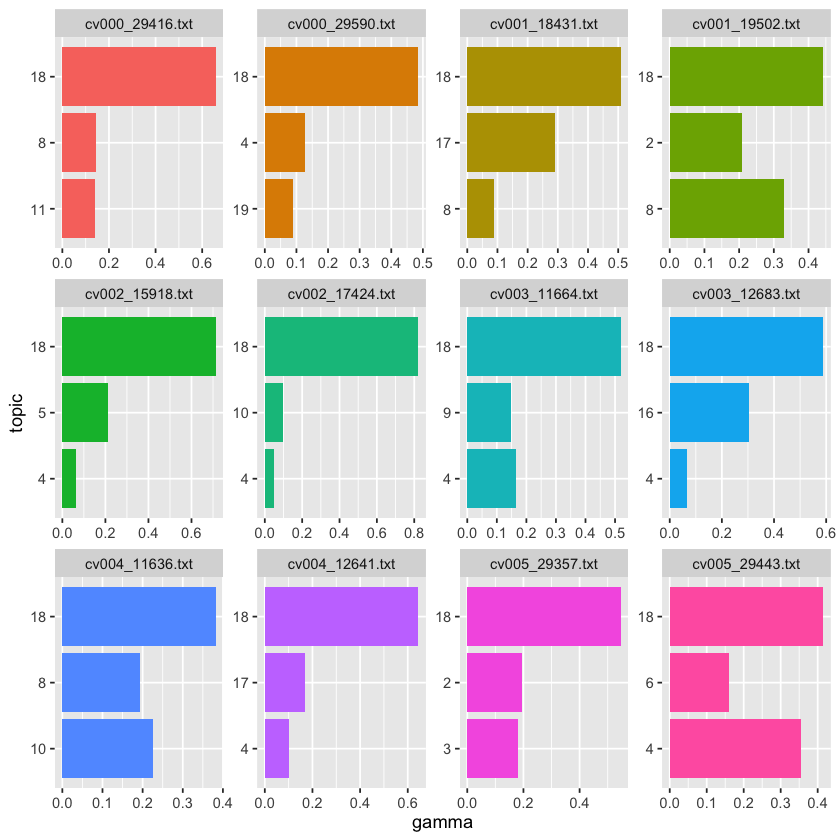

In [27]:
docs <- tidytext::tidy(tmod_20, matrix = "gamma")

head(docs, n=20)

docs_topics <-
  docs  |>
  group_by(document) |>   arrange(document, -gamma) |>
  slice_head(n=3) |> mutate(id = cur_group_id()) |> ungroup()


head(docs_topics)

docs_topics  |>  filter(id <=12) |>
  mutate(topic = reorder(topic, gamma))  |>
  ggplot(aes(topic, gamma, fill = factor(document))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ document, scales = "free") +
  coord_flip()


In [28]:
docs <- tidytext::tidy(tmod_20, matrix = "gamma")
levels(as.factor(docs$topic))
docs <- docs  %>% filter(topic !=17 & topic !=13)
levels(as.factor(docs$topic))



[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "13" "14" "15"
[16] "16" "17" "18" "19" "20"

[1] "1"  "2"  "3"  "4"  "5"  "6"  "7"  "8"  "9"  "10" "11" "12" "14" "15" "16"
[16] "18" "19" "20"

document,topic,gamma,id
<chr>,<int>,<dbl>,<int>
cv000_29416.txt,18,0.65846056,1
cv000_29416.txt,8,0.14637405,1
cv000_29416.txt,11,0.14001272,1
cv000_29590.txt,18,0.48538375,2
cv000_29590.txt,4,0.12703160,2
cv000_29590.txt,19,0.09034989,2


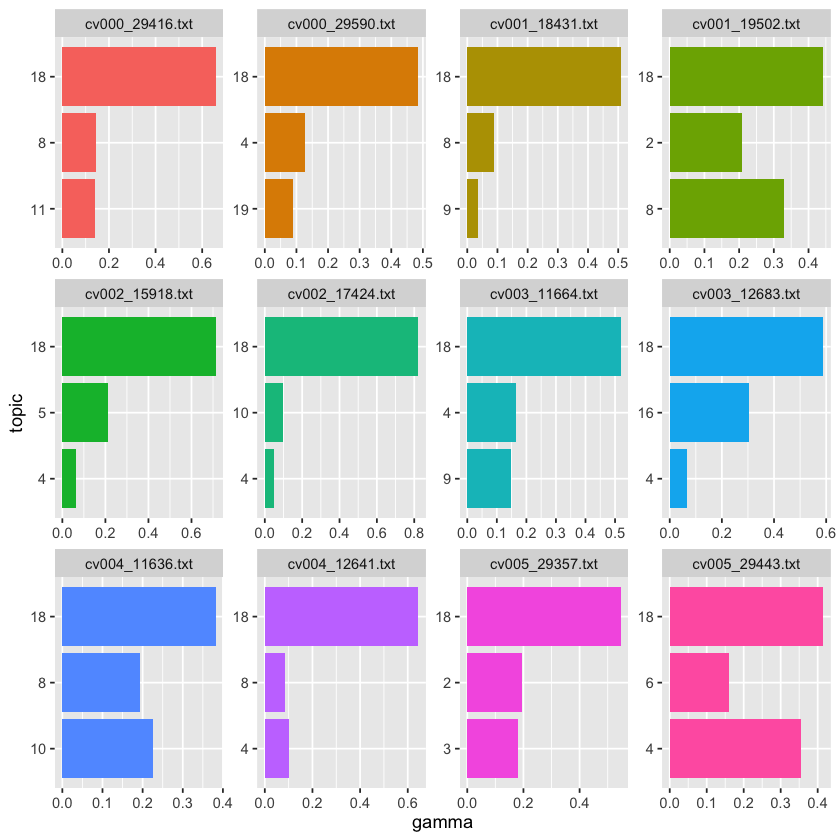

In [29]:

docs_topics <-
  docs  |>
  group_by(document) |>   arrange(document, -gamma) |>
  slice_head(n=3) |> mutate(id = cur_group_id()) |> ungroup()


head(docs_topics)

docs_topics  |>  filter(id <=12) |>
  mutate(topic = reorder(topic, gamma))  |>
  ggplot(aes(topic, gamma, fill = factor(document))) +
  geom_col(show.legend = FALSE) +
  facet_wrap(~ document, scales = "free") +
  coord_flip()


---

## IV. Perplexity

La **perplejidad** es una métrica de evaluación (*goodness-of-fit*) ampliamente utilizada para medir la calidad de modelos de lenguaje probabilísticos, como el modelo **Latent Dirichlet Allocation (LDA)**.

### 📌 ¿Qué mide?

Indica **cuán bien** un modelo predice un conjunto de datos **desconocido** (no visto durante el entrenamiento). En términos simples:

- 🔽 **Menor perplejidad** → mejor desempeño del modelo para generalizar y predecir.
- 🔼 **Mayor perplejidad** → el modelo tiene mayor incertidumbre y peor capacidad de predicción.

### 🧮 ¿Cómo se calcula?

Se basa en la **probabilidad promedio logarítmica inversa** que el modelo asigna a las palabras del conjunto de prueba. Si el modelo asigna **altas probabilidades** a las palabras verdaderas, su perplejidad será **baja**.


$\text{Perplexity}(D) = \exp\left\{-\frac{1}{N} \sum_{d \in D} \log p(w_d) \right\}$


donde:
- \( D \) es el conjunto de documentos de prueba.
- \( w_d \) son las palabras en el documento \( d \).
- $( p(w_d) )$ es la probabilidad de esas palabras según el modelo.
- \( N \) es el número total de palabras en \( D \).

### 📈 Aplicación en LDA

Cuando se entrena un modelo LDA con diferentes valores de \( k \) (número de tópicos), se puede comparar la **perplejidad** para encontrar el valor de \( k \) que mejor generaliza. Sin embargo, valores muy bajos de perplejidad pueden coincidir con **tópicos menos interpretables**, por lo que también se debe considerar la **coherencia temática**.

🔗 Recursos útiles:

- [Gráfico de perplejidad según número de tópicos (ResearchGate)](https://www.researchgate.net/figure/Perplexity-of-LDA-models-with-different-numbers-of-topics-and-alpha-Notes-The-line-graph_fig2_283671339)
- [Tutorial Quanteda - Topic Models](https://tutorials.quanteda.io/machine-learning/topicmodel/)


In [30]:
dfm <-dfmat
dtm <-dfmat_tm   #"Document Term Matrix" - Esta es nuesta dfm con el formato para aplicar topic modelling

---

## División del Corpus en Entrenamiento y Prueba

Para evaluar la capacidad predictiva de un modelo (como LDA), es común dividir el corpus en dos subconjuntos:

- **Entrenamiento (`train`)**: utilizado para ajustar el modelo.
- **Prueba (`test`)**: utilizado para evaluar qué tan bien generaliza el modelo a datos no vistos.

A continuación se muestra el procedimiento en R para realizar esta división a partir de una `Document-Term Matrix (dtm)`:

```r
# Selecciona aleatoriamente el 75% de los documentos
train = sample(rownames(dtm), nrow(dtm) * .75)

# Crea el conjunto de entrenamiento
dtm_train = dtm[rownames(dtm) %in% train, ]

# Crea el conjunto de prueba con el 25% restante
dtm_test = dtm[!rownames(dtm) %in% train, ]
```


In [31]:
train = sample(rownames(dtm), nrow(dtm) * .75)
dtm_train = dtm[rownames(dtm) %in% train, ]
dtm_test = dtm[!rownames(dtm) %in% train, ]

In [32]:
m = LDA(dtm_train, method = "Gibbs", k = 20,  control = list(alpha = 0.02, delta = 0.02))

In [33]:
perplexity(m, dtm_test)

[1] 3829.943

---

## Evaluación de Perplejidad para Distintos Valores de \( k \)

Una forma común de seleccionar el número óptimo de tópicos en un modelo LDA es mediante la **perplejidad**, una métrica que evalúa qué tan bien un modelo de lenguaje puede generalizar a datos nuevos.

En este experimento, se entrena un modelo LDA para distintos valores de \( k \) (número de tópicos) y se calcula su perplejidad usando un conjunto de prueba independiente. El procedimiento se realiza sobre los siguientes valores de \( k \):  
**5, 10, 15, 20, 25, 30, 35, 40, 45, 50, 55 y 60**.

Para cada valor de \( k \), se construye un modelo LDA utilizando **Gibbs Sampling** con parámetros de suavizado fijos (alpha y delta = 0.02). Luego, se evalúa su capacidad de predicción sobre el conjunto de test calculando su perplejidad.

📌 **Interpretación de la perplejidad**:
- Una perplejidad **más baja** indica un mejor ajuste del modelo al capturar la estructura latente del texto.
- Una perplejidad **alta** sugiere que el modelo no generaliza bien a nuevos datos (es decir, hace malas predicciones sobre el contenido).

⚠️ Este procedimiento puede tardar **más de 20 minutos**, dependiendo del tamaño del corpus y la capacidad de procesamiento del equipo.

🎯 El objetivo es encontrar un valor de \( k \) que ofrezca un buen equilibrio entre complejidad del modelo y capacidad explicativa sin sobreajuste.


In [34]:
## crear un marco de datos para almacenar el perplexity para diferentes valores de k (esto se demora 22 minutos en el Alienware)
p = data.frame(k = c(5,10,15,20,25,30,35,40,45,50,55,60), perplexity = NA)

## recorrer los valores de k en data.frame p
for (i in 1:nrow(p)) {
  print(p$k[i])
  m = LDA(dtm_train, method = "Gibbs", k = p$k[i],  control = list(alpha = 0.02, delta = 0.02))
  p$perplexity[i] = perplexity(m, dtm_test)
}

head(p)

[1] 5
[1] 10
[1] 15
[1] 20
[1] 25
[1] 30
[1] 35
[1] 40
[1] 45
[1] 50
[1] 55
[1] 60


,k,perplexity
,<dbl>,<dbl>
1,5,4204.967
2,10,4019.231
3,15,3907.472
4,20,3823.316
5,25,3763.834
6,30,3707.552


## Escogiendo $k$ : *The Elbow Method*

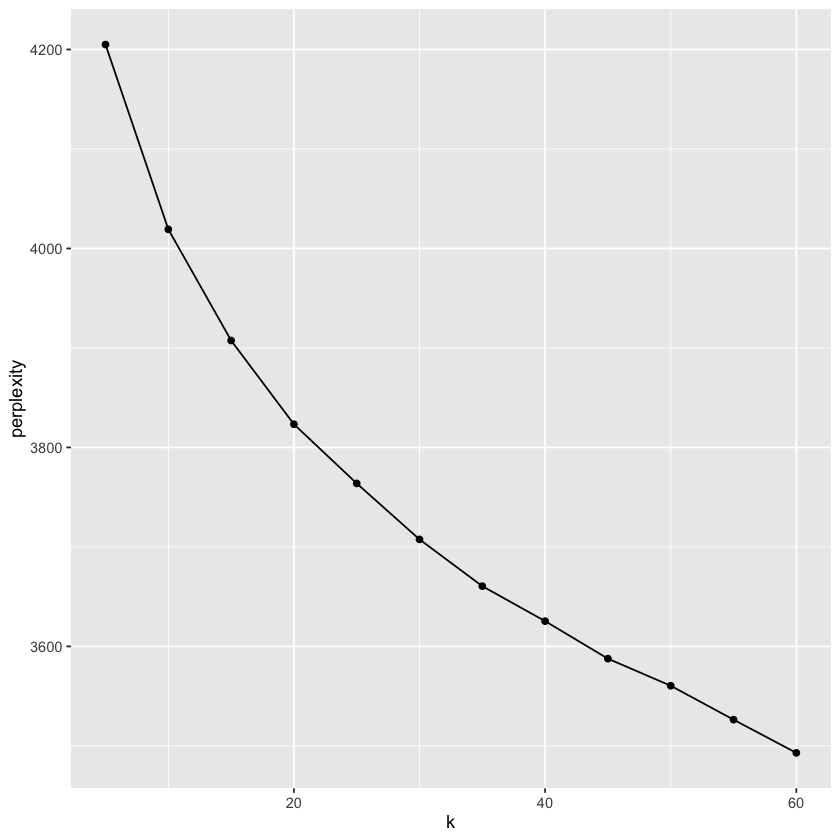

In [35]:
ggplot(p, aes(x=k, y=perplexity)) + geom_line() + geom_point()

In [36]:
p
str(p)


k,perplexity
<dbl>,<dbl>
5,4204.967
10,4019.231
15,3907.472
20,3823.316
25,3763.834
30,3707.552
35,3660.537
40,3625.386
45,3587.656


'data.frame':	12 obs. of  2 variables:
 $ k         : num  5 10 15 20 25 30 35 40 45 50 ...
 $ perplexity: num  4205 4019 3907 3823 3764 ...


https://stackoverflow.com/questions/71856782/elbow-method-for-optimal-no-of-clusters

https://community.ibm.com/community/user/ai-datascience/blogs/moloy-de1/2020/07/02/points-to-ponder

https://www.researchgate.net/figure/Example-of-the-elbow-criterion-applied-over-the-curve-of-within-class-sum-of-squares-per_fig1_281443471

Warning message in geom_segment(aes(x = k[1], y = perplexity[1], xend = k[12], yend = perplexity[12]), :
"All aesthetics have length 1, but the data has 12 rows.
i Please consider using `annotate()` or provide this layer with data containing
  a single row."


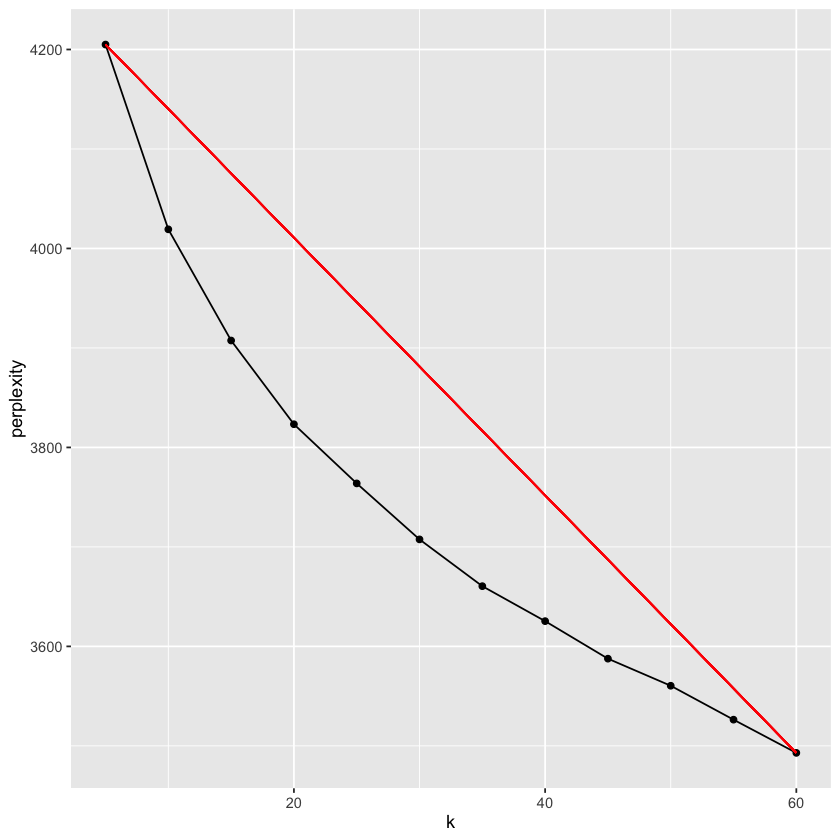

In [37]:
p  %>% ggplot(aes(x=k, y=perplexity)) + geom_line() + geom_point() +
       geom_segment(aes(x = k[1], y = perplexity[1], xend = k[12], yend = perplexity[12]), col="red")



### **Distancia de un Punto a una Recta**

Considere la recta:

$L: y=mx + n$ y el punto $P=(a,b)$

La distancia entre el punto y la recta viene dada por:

$d(P,L)= \frac{ | b-m\cdot a-n | }{ \sqrt{a^2+1} } $  



https://www.superprof.es/apuntes/escolar/matematicas/analitica/distancias/distancia-de-un-punto-a-una-recta.html

https://es.wikipedia.org/wiki/Distancia_de_un_punto_a_una_recta


In [38]:
# Esta función calcula la distancia entre el punto "P" y la recta L.

dist_PL <- function(m,n,Px,Py) {
    d <- (abs(Py-m*Px-n))/sqrt(m^2+1)
} 

¿Cuál es la distancia del segundo punto (k=10) a la recta?

La pendiente es:

In [39]:
m <- (p$perplexity[nrow(p)]-p$perplexity[1])/ (p$k[nrow(p)]-p$k[1])
m

[1] -12.94543

El intercepto es:

In [40]:
n <- p$perplexity[nrow(p)]-m*p$k[nrow(p)]
n

[1] 4269.694

In [41]:
d <- dist_PL(m,n,p$k[2],p$perplexity[2])
d

[1] 9.3198

Calculemos las distancias de todos los puntos a la recta: 

In [42]:
dist_vector = data.frame(k = c(5,10,15,20,25,30,35,40,45,50,55,60), dist = NA) #En este vector guardamos las distancias

In [43]:
for (i in 1:nrow(p)) {
  dist_vector$dist[i] = dist_PL(m,n,p$k[i],p$perplexity[i])
}

In [44]:
dist_vector


k,dist
<dbl>,<dbl>
5,0.000000
10,9.319800
15,12.942089
20,14.438486
25,14.034457
30,13.384050
35,12.019896
40,9.742035
45,7.662778


In [45]:
print(dist_vector$k[which.max(dist_vector$dist)])


[1] 20


El número óptimo de tópicos es entonces 20.

Y....¿si hacemos el gráfico?

In [46]:
# Pendiente de la Recta
m0 = (p$perplexity[nrow(p)] - p$perplexity[1] )/(p$k[nrow(p)] - p$k[1])
m0
m1 = -1/m0
m1

# Intercepto

a = p$perplexity[which.max(dist_vector$dist)]-m1*p$k[which.max(dist_vector$dist)]
a


[1] -12.94543

[1] 0.07724732

[1] 3821.771

Warning message in geom_segment(aes(x = k[1], y = perplexity[1], xend = k[12], yend = perplexity[12]), :
"All aesthetics have length 1, but the data has 12 rows.
i Please consider using `annotate()` or provide this layer with data containing
  a single row."


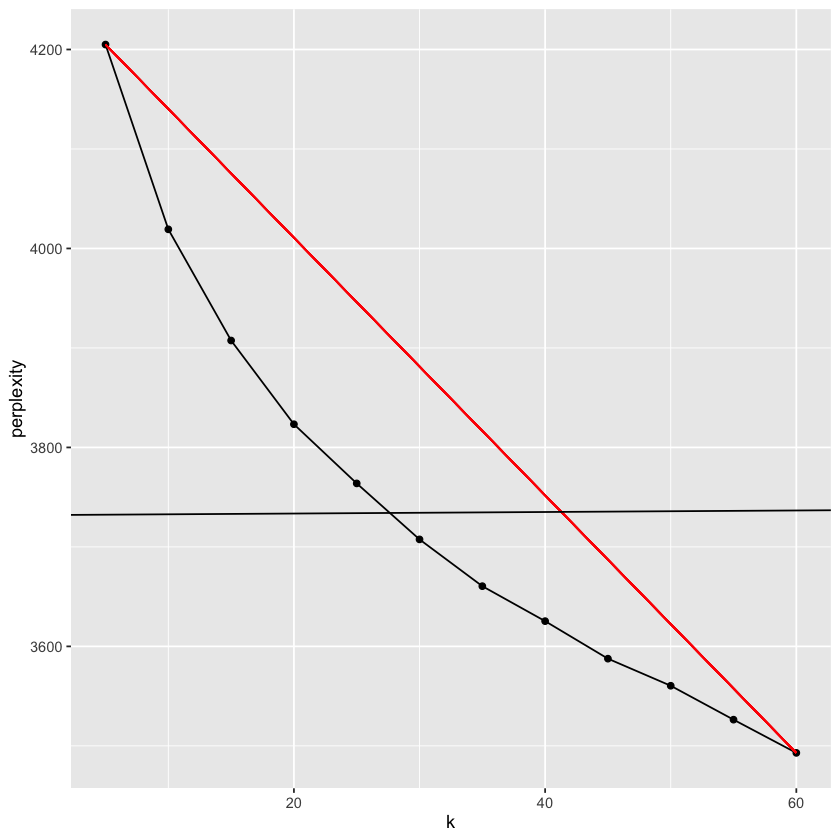

In [47]:
p  %>% ggplot(aes(x=k, y=perplexity)) + geom_line() + geom_point() +
       geom_segment(aes(x = k[1], y = perplexity[1], xend = k[12], yend = perplexity[12]), col="red") + 
       geom_abline(intercept = 3732, slope = m1)